# Class 6 — FDE Data Validation with FlashEats

Yesterday, you proved you could **retrieve** data from multiple systems.

Today the question is different:

> **Can we safely use that data to make a business decision?**

This is not a generic data-cleaning lab.

## FDE validation mindset

**Business claim → assumptions → validation contract → targeted checks → stakeholder clarification → PASS / WARN / FAIL → publish decision**

### Concepts

**1. Validation is decision-dependent**  
A field can be good enough for weekly reporting but unsafe for a live operational decision.

**2. Turn assumptions into contracts**  
Business assumption → data expectation → executable check → action.

**3. Separate three validation types**
- Technical: chronology, IDs, categories, mappings
- Semantic: what does a status or ETA actually mean?
- Organizational: who owns the KPI definition?

**4. Never silently fix ambiguity**  
Do not encode thresholds or category mappings without ownership.

**5. Output a validation gate**  
The deliverable is not merely a cleaned dataframe. It is a decision:
PASS / WARN / FAIL / UNKNOWN.

In [1]:
import json
import sqlite3
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 200)

# The notebook runs from exercises/, the classroom pack sits next to it
BASE = Path("FlashEats_Classroom_Pack_V2")
DB_PATH = BASE / "database" / "flasheats.db"

if not DB_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DB_PATH}. Run this notebook from the folder that contains FlashEats_Classroom_Pack_V2."
    )
print("BASE:", BASE)
print("Database found:", DB_PATH.exists())

BASE: FlashEats_Classroom_Pack_V2
Database found: True


## Load the updated FlashEats data

In [2]:
con = sqlite3.connect(BASE / "database" / "flasheats.db")

orders = pd.read_sql("SELECT * FROM orders", con)
restaurants = pd.read_sql("SELECT * FROM restaurants", con)
drivers = pd.read_sql("SELECT * FROM drivers", con)

tickets = pd.read_csv(BASE / "data" / "support_tickets.csv")
restaurant_status = pd.read_csv(BASE / "data" / "restaurant_status.csv")

with open(BASE / "data" / "client_metric_definitions.json", "r") as f:
    metric_notes = json.load(f)

print("orders:", orders.shape)
print("tickets:", tickets.shape)
print("restaurant_status:", restaurant_status.shape)

display(orders.head())
display(tickets.head())
display(restaurant_status.head())
print(json.dumps(metric_notes, indent=2))

orders: (1603, 13)
tickets: (202, 5)
restaurant_status: (502, 4)


,order_id,customer_id,restaurant_id,driver_id,city,created_at,promised_eta,pickup_at,actual_delivery_at,final_status,distance_km_estimate,traffic_bucket,weather_bucket
0,O00001,C0168,R009,D103,Bengaluru,2026-08-13T12:56:00,2026-08-13T14:11:36,2026-08-13T13:35:49.825561,2026-08-13T14:22:25.035899,delivered,18.00,medium,clear
1,O00002,C0043,R018,D083,Bengaluru,2026-08-01T18:36:00,2026-08-01T19:43:16.627988,2026-08-01T18:58:24.735336,2026-08-01T19:47:14.818533,delivered,9.37,severe,clear
2,O00003,C0855,R010,D039,Bengaluru,2026-08-01T19:35:00,2026-08-01T20:17:52.941967,2026-08-01T19:57:50.820366,2026-08-01T20:13:28.061191,delivered,2.42,medium,clear
3,O00004,C0229,R030,D038,Bengaluru,2026-08-09T18:16:00,2026-08-09T19:30:19.067006,2026-08-09T18:46:48.725485,NaN,cancelled,14.20,high,rain
4,O00005,C0040,R004,D047,Bengaluru,2026-08-06T20:35:00,2026-08-06T21:54:48,2026-08-06T21:18:38.024280,2026-08-06T22:15:49.290713,delivered,18.00,high,clear


,ticket_id,order_id,created_at,category,customer_message
0,T00001,NaN,2026-08-26T23:34:00,late_delivery,My order is already past the promised time.
1,T00002,NaN,2026-08-24T13:49:00,eta_changed,The ETA keeps changing and the food is still not here.
2,T00003,NaN,2026-08-25T18:22:00,status_mismatch,The app says picking up but the restaurant says it is ready.
3,T00004,O00037,2026-08-09T21:09:00,Late Delivery,The rider has not moved for 15 minutes.
4,T00005,O00040,2026-08-11T20:15:00,late_delivery,My order is already past the promised time.


,order_id,restaurant_id,status,last_updated_at
0,O00676,R040,READY,2026-08-17T13:29:00
1,O01506,R055,Ready,2026-08-27T16:37:00
2,O01484,R032,ready,2026-08-08T19:44:00
3,O00675,R012,handoff,2026-08-22T21:42:00
4,O00078,R027,unknown,2026-08-25T19:35:00


{
  "metric_under_review": "Late Delivery Rate",
  "leadership_claim": "Late Delivery Rate is 56%",
  "stakeholders": {
    "VP Operations": "Any delivered order after the promised ETA is late.",
    "Support Lead": "Only more than 10 minutes beyond ETA should count as meaningfully late.",
    "Finance": "Cancelled/refunded orders should not count in operational performance.",
    "Data Team": "Historical dashboard uses delivered orders with non-null actual delivery time."
  },
  "note": "No canonical KPI owner is formally documented."
}


# Challenge 1 — Can we defend the “56% late” claim?


Leadership says:

> **“Late Delivery Rate is 56%.”**

Before calculating anything, create a validation contract.

| Business assumption | Data expectation | How will you test it? | Severity if false |
|---|---|---|---|
| One row = one business order | `order_id` is unique in `orders` | `COUNT(*)` vs `COUNT(DISTINCT order_id)`, then compare the duplicate rows column by column | High: orders get counted twice and can carry two different traffic labels |
| Delivered orders have completion time | every delivered order (any casing) has `actual_delivery_at` | count delivered rows with NULL `actual_delivery_at` | High: those orders silently fall out of the denominator |
| Promised ETA is valid | `promised_eta` is after `created_at`, and it's the ETA the customer saw | count `promised_eta < created_at`; compare ticket times with `promised_eta` | High: a bad ETA creates fake delays, and the wrong ETA changes what "late" means |
| Event chronology is valid | created <= pickup <= delivered; cancelled orders have no pickup/delivery | pairwise timestamp comparisons in SQL | Medium: few rows, but phase durations go wrong |
| “Late” has an agreed definition | one written definition with a named owner | read `client_metric_definitions.json`, recompute under each version | High: the headline number can swing a lot |

**Hint:** Don't start by cleaning. Ask: *what could make 56% misleading?*

In [3]:
print("Rows:", len(orders))
print("Unique orders:", orders["order_id"].nunique())
print(orders["final_status"].value_counts(dropna=False))

# technical checks in SQL. Grain check on raw rows, the rest on 1 row per order (first row wins)
checks = pd.read_sql("""
WITH d AS (
    SELECT *, LOWER(TRIM(final_status)) AS st,
           ROW_NUMBER() OVER (PARTITION BY order_id ORDER BY rowid) AS rn
    FROM orders
),
u AS (SELECT * FROM d WHERE rn = 1)
SELECT 'extra rows for an existing order_id' AS check_name, (SELECT COUNT(*) FROM d WHERE rn > 1) AS failing
UNION ALL SELECT 'status stored with different casing', (SELECT SUM(final_status <> st) FROM u)
UNION ALL SELECT 'delivered but actual_delivery_at is NULL', (SELECT SUM(st = 'delivered' AND actual_delivery_at IS NULL) FROM u)
UNION ALL SELECT 'promised_eta earlier than created_at', (SELECT SUM(julianday(promised_eta) < julianday(created_at)) FROM u)
UNION ALL SELECT 'pickup_at earlier than created_at', (SELECT SUM(julianday(pickup_at) < julianday(created_at)) FROM u)
UNION ALL SELECT 'actual_delivery_at earlier than pickup_at', (SELECT SUM(julianday(actual_delivery_at) < julianday(pickup_at)) FROM u)
UNION ALL SELECT 'cancelled but has a pickup_at', (SELECT SUM(st = 'cancelled' AND pickup_at IS NOT NULL) FROM u)
UNION ALL SELECT 'cancelled but has actual_delivery_at', (SELECT SUM(st = 'cancelled' AND actual_delivery_at IS NOT NULL) FROM u)
""", con)
display(checks)

Rows: 1603
Unique orders: 1600
final_status
delivered    1530
cancelled      68
Delivered       5
Name: count, dtype: int64


,check_name,failing
0,extra rows for an existing order_id,3
1,status stored with different casing,5
2,delivered but actual_delivery_at is NULL,37
3,promised_eta earlier than created_at,4
4,pickup_at earlier than created_at,0
5,actual_delivery_at earlier than pickup_at,5
6,cancelled but has a pickup_at,68
7,cancelled but has actual_delivery_at,0


In [4]:
# what actually differs between the duplicate rows?
dup = orders[orders["order_id"].duplicated(keep=False)]
for oid, g in dup.groupby("order_id"):
    differing = [c for c in g.columns if g[c].nunique(dropna=False) > 1]
    print(oid, "-> columns that differ:", differing, "| values:", g["traffic_bucket"].tolist())

# the rows behind the chronology failures
display(pd.read_sql("""
SELECT order_id, created_at, promised_eta, pickup_at, actual_delivery_at, final_status,
       CASE WHEN julianday(promised_eta) < julianday(created_at) THEN 'eta before created'
            ELSE 'delivered before pickup' END AS problem
FROM orders
WHERE julianday(promised_eta) < julianday(created_at)
   OR julianday(actual_delivery_at) < julianday(pickup_at)
ORDER BY problem, order_id
""", con))

O00120 -> columns that differ: ['traffic_bucket'] | values: ['severe', 'medium']
O00723 -> columns that differ: ['traffic_bucket'] | values: ['medium', 'high']
O01302 -> columns that differ: ['traffic_bucket'] | values: ['medium', 'high']


,order_id,created_at,promised_eta,pickup_at,actual_delivery_at,final_status,problem
0,O00051,2026-08-01T15:09:00,2026-08-01T16:28:30.928528,2026-08-01T16:24:51.495665,2026-08-01T16:19:51.495665,delivered,delivered before pickup
1,O00052,2026-08-24T17:07:00,2026-08-24T18:26:48,2026-08-24T18:16:16.946011,2026-08-24T18:11:16.946011,delivered,delivered before pickup
2,O00053,2026-08-13T17:06:00,2026-08-13T17:58:50.809718,2026-08-13T18:25:53.797613,2026-08-13T18:20:53.797613,delivered,delivered before pickup
3,O00054,2026-08-28T19:56:00,2026-08-28T21:15:48,2026-08-28T21:25:10.582862,2026-08-28T21:20:10.582862,delivered,delivered before pickup
4,O00055,2026-08-16T12:53:00,2026-08-16T14:05:48,2026-08-16T14:08:05.645770,2026-08-16T14:03:05.645770,delivered,delivered before pickup
5,O00101,2026-08-24T20:59:00,2026-08-24T20:49:00,2026-08-24T21:25:03.983984,2026-08-24T22:14:30.685278,delivered,eta before created
6,O00102,2026-08-11T16:41:00,2026-08-11T16:31:00,2026-08-11T17:05:05.809584,2026-08-11T17:57:17.661772,delivered,eta before created
7,O00103,2026-08-22T20:11:00,2026-08-22T20:01:00,2026-08-22T20:39:45.064627,2026-08-22T21:10:17.342305,delivered,eta before created
8,O00104,2026-08-09T22:19:00,2026-08-09T22:09:00,2026-08-09T22:47:33.934776,2026-08-09T23:36:20.740161,delivered,eta before created


In [5]:
# semantic check: is promised_eta the ETA the customer was shown?
# tickets like "already past the promised time" should come AFTER the promise
t = tickets.drop_duplicates().dropna(subset=["order_id"]).merge(
    orders.drop_duplicates("order_id")[["order_id", "promised_eta"]], on="order_id", how="left", validate="many_to_one")
t["opened_before_eta"] = pd.to_datetime(t["created_at"], format="mixed") < pd.to_datetime(t["promised_eta"], format="mixed")
print("linked tickets:", len(t), "| opened before promised_eta:", int(t["opened_before_eta"].sum()))
late_msgs = t[t["customer_message"].str.contains("past the promised time")]
print("'already past the promised time' tickets:", len(late_msgs),
      "| of those opened before promised_eta:", int(late_msgs["opened_before_eta"].sum()))

c = checks.set_index("check_name")["failing"]
needs_owner = pd.DataFrame([
    ("One row = one business order", f"FAIL: {c['extra rows for an existing order_id']} extra rows", "yes - which duplicate row is correct?"),
    ("Delivered orders have completion time", f"FAIL: {c['delivered but actual_delivery_at is NULL']} missing", "yes - how to treat them in the KPI"),
    ("Promised ETA is valid", f"FAIL: {c['promised_eta earlier than created_at']} impossible + ticket timing doubt", "yes - which ETA is the promise"),
    ("Event chronology is valid", f"WARN: {c['actual_delivery_at earlier than pickup_at']} delivered before pickup, "
                                  f"{c['cancelled but has a pickup_at']} cancelled with pickup_at", "partly - what pickup_at means for cancelled"),
    ("'Late' has an agreed definition", metric_notes["note"], "yes - this is the main one"),
], columns=["assumption", "result", "needs stakeholder clarification?"])
display(needs_owner)

linked tickets: 198 | opened before promised_eta: 192
'already past the promised time' tickets: 37 | of those opened before promised_eta: 37


,assumption,result,needs stakeholder clarification?
0,One row = one business order,FAIL: 3 extra rows,yes - which duplicate row is correct?
1,Delivered orders have completion time,FAIL: 37 missing,yes - how to treat them in the KPI
2,Promised ETA is valid,FAIL: 4 impossible + ticket timing doubt,yes - which ETA is the promise
3,Event chronology is valid,"WARN: 5 delivered before pickup, 68 cancelled with pickup_at",partly - what pickup_at means for cancelled
4,'Late' has an agreed definition,No canonical KPI owner is formally documented.,yes - this is the main one


- Grain: 1603 rows, 1600 orders. The 3 duplicates (O00120, O00723, O01302) differ only in `traffic_bucket`, so the late rate doesn't care which row I keep, but a traffic breakdown does.
- 37 delivered orders have no `actual_delivery_at`, and 5 are stored as "Delivered".
- 4 orders (O00101 to O00104) have `promised_eta` 10 min before `created_at`.
- 5 orders (O00051 to O00055) are delivered 5 min before `pickup_at`, and all 68 cancelled orders have a `pickup_at`.
- 192 of 198 linked tickets (and all 37 "already past the promised time" ones) were opened before `promised_eta`. So `promised_eta` may not be the ETA the customer saw.

Questions I'd ask the owners:
- Platform team: which of the duplicate rows is right?
- Platform team: is `promised_eta` the checkout ETA or the latest one?
- Ops / Data Team: what should the KPI do with delivered orders that have no delivery time?
- Leadership: who owns the Late Delivery Rate definition?

# Challenge 2 — Stakeholders disagree on “late”


Read `client_metric_definitions.json`.

Calculate the metric under at least three definitions:
- any delay > 0 minutes,
- delay > 10 minutes,
- historical-style delivered/non-null population.

| Definition | Late rate | Business meaning |
|---|---:|---|

Then answer:

> **Which one should leadership publish, and who must own that decision?**

In [6]:
analysis = orders.drop_duplicates("order_id", keep="first").copy()

for c in ["promised_eta", "actual_delivery_at"]:
    analysis[c] = pd.to_datetime(analysis[c], format="mixed", errors="coerce")

analysis["delay_min"] = (
    analysis["actual_delivery_at"] - analysis["promised_eta"]
).dt.total_seconds() / 60

# the same definitions in SQL, one row per definition
defs = pd.read_sql("""
WITH d AS (
    SELECT *, LOWER(TRIM(final_status)) AS st,
           (julianday(actual_delivery_at) - julianday(promised_eta)) * 1440 AS delay_min,
           ROW_NUMBER() OVER (PARTITION BY order_id ORDER BY rowid) AS rn
    FROM orders
),
u AS (SELECT * FROM d WHERE rn = 1)
SELECT 'VP Ops: any delay > 0, delivered with a time' AS definition,
       SUM(delay_min > 0) AS late, COUNT(*) AS denominator
FROM u WHERE st = 'delivered' AND actual_delivery_at IS NOT NULL
UNION ALL
SELECT 'Support: delay > 10 min, delivered with a time', SUM(delay_min > 10), COUNT(*)
FROM u WHERE st = 'delivered' AND actual_delivery_at IS NOT NULL
UNION ALL
SELECT 'Finance: all non-cancelled orders, no time = not late', SUM(delay_min > 0), COUNT(*)
FROM u WHERE st <> 'cancelled'
UNION ALL
SELECT 'Data Team historical: raw rows, final_status = ''delivered'', time not null', SUM(delay_min > 0), COUNT(*)
FROM d WHERE final_status = 'delivered' AND actual_delivery_at IS NOT NULL
UNION ALL
SELECT 'Data Team, raw rows but case-insensitive status', SUM(delay_min > 0), COUNT(*)
FROM d WHERE st = 'delivered' AND actual_delivery_at IS NOT NULL
UNION ALL
SELECT 'All 1600 orders in denominator (cancelled count as not late)', SUM(delay_min > 0), COUNT(*)
FROM u
UNION ALL
SELECT 'VP Ops, minus the 4 orders with ETA before creation', SUM(delay_min > 0), COUNT(*)
FROM u WHERE st = 'delivered' AND actual_delivery_at IS NOT NULL AND julianday(promised_eta) >= julianday(created_at)
""", con)
defs["late_rate_pct"] = (100 * defs["late"] / defs["denominator"]).round(2)
display(defs)

# cross-check the first row with the pandas version above
valid = analysis[analysis["final_status"].str.lower().eq("delivered") & analysis["actual_delivery_at"].notna()]
print("pandas check, any delay > 0:", round(100 * (valid["delay_min"] > 0).mean(), 2), "% of", len(valid))
print("is 'refunded' a status in orders?", "refunded" in orders["final_status"].str.lower().unique())

,definition,late,denominator,late_rate_pct
0,"VP Ops: any delay > 0, delivered with a time",843,1495,56.39
1,"Support: delay > 10 min, delivered with a time",349,1495,23.34
2,"Finance: all non-cancelled orders, no time = not late",843,1532,55.03
3,"Data Team historical: raw rows, final_status = 'delivered', time not null",841,1493,56.33
4,"Data Team, raw rows but case-insensitive status",844,1498,56.34
5,All 1600 orders in denominator (cancelled count as not late),843,1600,52.69
6,"VP Ops, minus the 4 orders with ETA before creation",839,1491,56.27


pandas check, any delay > 0: 56.39 % of 1495
is 'refunded' a status in orders? False


{0: 56.39, 1: 52.17, 2: 47.89, 3: 44.48, 4: 40.94, 5: 37.46, 6: 34.85, 7: 30.84, 8: 28.29, 9: 25.55, 10: 23.34, 11: 21.81, 12: 20.0, 13: 17.39, 14: 15.59, 15: 13.91}


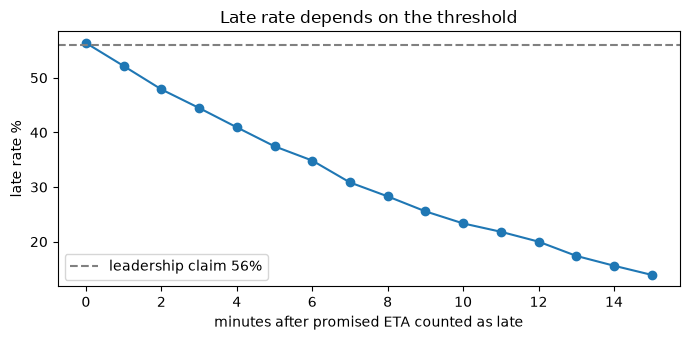

In [7]:
# how the rate moves with the threshold (same population as VP Ops)
thresholds = list(range(0, 16))
rates = [round(float(100 * (valid["delay_min"] > t).mean()), 2) for t in thresholds]
print(dict(zip(thresholds, rates)))
plt.figure(figsize=(7, 3.5))
plt.plot(thresholds, rates, marker="o")
plt.axhline(56, color="grey", linestyle="--", label="leadership claim 56%")
plt.xlabel("minutes after promised ETA counted as late")
plt.ylabel("late rate %")
plt.title("Late rate depends on the threshold")
plt.legend()
plt.tight_layout()
plt.show()

| Definition | Late rate | Business meaning |
|---|---:|---|
| VP Ops: any delay > 0 | 56.39% (843/1495) | any missed promise counts |
| Support: > 10 min | 23.34% (349/1495) | only delays customers notice |
| Finance: all non-cancelled orders | 55.03% (843/1532) | missing times count as not late; there's no "refunded" status to exclude |
| Data Team historical (raw, exact 'delivered') | 56.33% (841/1493) | old dashboard style, duplicates included |
| All 1600 orders | 52.69% | cancelled count as not late |

56% is reproduced by the VP Ops (56.39%) or the historical query (56.33%). The threshold matters most: 37.46% at 5 min, 23.34% at 10.

I'd publish the any-delay number with the > 10 min rate next to it. But the file says no KPI owner is documented, so leadership has to name one person to sign off threshold, denominator and cancellations, with Support, Finance and the Data Team agreeing.

# Challenge 3 — Validate categories without cleaning by instinct


Inspect:
- `final_status`
- `traffic_bucket`
- restaurant `status`
- support-ticket `category`

For each:
1. list observed values,
2. identify representation differences,
3. decide what is safe to normalize,
4. identify what requires owner confirmation.

Remember:

> `"Delivered"` vs `"delivered"` is likely representation.  
> `"handoff"` vs `"handed_off"` may be semantics.

In [8]:
for col in ["final_status", "traffic_bucket"]:
    print("\n", col)
    print(orders[col].value_counts(dropna=False))

print("\nRestaurant status")
print(restaurant_status["status"].value_counts(dropna=False))

print("\nSupport category")
print(tickets["category"].value_counts(dropna=False))


 final_status
final_status
delivered    1530
cancelled      68
Delivered       5
Name: count, dtype: int64

 traffic_bucket
traffic_bucket
medium    635
high      448
low       381
severe    136
HIGH        3
Name: count, dtype: int64

Restaurant status
status
preparing     171
handed_off    168
ready         157
ready           2
READY           1
Ready           1
handoff         1
unknown         1
Name: count, dtype: int64

Support category
category
late_delivery        38
eta_changed          37
restaurant_delay     37
ready_but_waiting    33
status_mismatch      29
driver_not_moving    25
Late Delivery         1
late_delivery         1
ETA issue             1
Name: count, dtype: int64


In [9]:
# repr() makes trailing spaces visible
for name, s in [("restaurant status", restaurant_status["status"]), ("ticket category", tickets["category"])]:
    print(name, s.map(repr).unique().tolist())

SEMANTIC = {"handoff", "unknown"}   # clean spelling, unclear meaning

def decide(raw, clean_values):
    v = raw.strip().lower()
    if v in SEMANTIC:
        return "ask owner (meaning)"
    if raw == v:
        return "keep"
    if v in clean_values:
        return "safe: case/space only"
    if v.replace(" ", "_") in clean_values:
        return "probably safe, confirm"
    return "ask owner (meaning)"

rows = []
for field, s in [("final_status", orders["final_status"]), ("traffic_bucket", orders["traffic_bucket"]),
                 ("restaurant status", restaurant_status["status"]), ("ticket category", tickets["category"])]:
    counts = s.value_counts()
    clean_values = {v for v in counts.index if v == v.strip().lower()} - SEMANTIC
    for raw, n in counts.items():
        rows.append({"field": field, "raw_value": repr(raw), "rows": n,
                     "normalised": raw.strip().lower(), "decision": decide(raw, clean_values)})
cat_map = pd.DataFrame(rows)
display(cat_map)

restaurant status ["'READY'", "'Ready'", "'ready '", "'handoff'", "'unknown'", "'handed_off'", "'ready'", "'preparing'"]
ticket category ["'late_delivery'", "'eta_changed'", "'status_mismatch'", "'Late Delivery'", "'late_delivery '", "'ETA issue'", "'restaurant_delay'", "'ready_but_waiting'", "'driver_not_moving'"]


,field,raw_value,rows,normalised,decision
0,final_status,'delivered',1530,delivered,keep
1,final_status,'cancelled',68,cancelled,keep
2,final_status,'Delivered',5,delivered,safe: case/space only
3,traffic_bucket,'medium',635,medium,keep
4,traffic_bucket,'high',448,high,keep
5,traffic_bucket,'low',381,low,keep
6,traffic_bucket,'severe',136,severe,keep
7,traffic_bucket,'HIGH',3,high,safe: case/space only
8,restaurant status,'preparing',171,preparing,keep
9,restaurant status,'handed_off',168,handed_off,keep


| Field | Observed values | Safe to normalise | Needs owner |
|---|---|---|---|
| `final_status` | delivered 1530, cancelled 68, Delivered 5 | Delivered -> delivered | no refunded status although Finance mentions refunds |
| `traffic_bucket` | medium, high, low, severe, HIGH 3 | HIGH -> high | bucket cut-offs, the 3 duplicates |
| restaurant `status` | preparing, handed_off, ready (+ 'ready ', READY, Ready), handoff 1, unknown 1 | ready variants -> ready | handoff vs handed_off, what unknown means |
| ticket `category` | 6 clean values + 'Late Delivery', 'late_delivery ', 'ETA issue' | 'late_delivery ' -> late_delivery ('Late Delivery' probably too) | 'ETA issue' = eta_changed? |

I only fixed case and whitespace. handoff, unknown and ETA issue stay as they are until someone confirms what they mean.

# Challenge 4 — Cross-source integrity


Validate mappings:
- `orders.restaurant_id` → restaurants
- `orders.driver_id` → drivers
- `tickets.order_id` → orders
- `restaurant_status.order_id` → orders

Produce:

| Relationship | Coverage % | Status | Risk |
|---|---:|---|---|

Then discuss:

> If 1% is unmapped, is that acceptable?

It depends on which business decision uses those records.

In [10]:
# order-side relationships in SQL (one row per order)
db_cov = pd.read_sql("""
WITH u AS (
    SELECT *, ROW_NUMBER() OVER (PARTITION BY order_id ORDER BY rowid) AS rn FROM orders
)
SELECT 'orders.restaurant_id -> restaurants' AS relationship,
       COUNT(*) AS rows_checked,
       SUM(u.restaurant_id IS NULL) AS null_keys,
       SUM(r.restaurant_id IS NOT NULL) AS matched
FROM u LEFT JOIN restaurants r ON u.restaurant_id = r.restaurant_id WHERE u.rn = 1
UNION ALL
SELECT 'orders.driver_id -> drivers', COUNT(*), SUM(u.driver_id IS NULL), SUM(dr.driver_id IS NOT NULL)
FROM u LEFT JOIN drivers dr ON u.driver_id = dr.driver_id WHERE u.rn = 1
UNION ALL
SELECT 'orders.customer_id -> customers', COUNT(*), SUM(u.customer_id IS NULL), SUM(c.customer_id IS NOT NULL)
FROM u LEFT JOIN customers c ON u.customer_id = c.customer_id WHERE u.rn = 1
""", con)

# CSV-side relationships in pandas
order_ids = set(orders["order_id"])
csv_cov = pd.DataFrame([
    {"relationship": "tickets.order_id -> orders", "rows_checked": len(tickets),
     "null_keys": int(tickets["order_id"].isna().sum()), "matched": int(tickets["order_id"].isin(order_ids).sum())},
    {"relationship": "restaurant_status.order_id -> orders", "rows_checked": len(restaurant_status),
     "null_keys": int(restaurant_status["order_id"].isna().sum()), "matched": int(restaurant_status["order_id"].isin(order_ids).sum())},
])
coverage = pd.concat([db_cov, csv_cov], ignore_index=True)
coverage["coverage_pct"] = (100 * coverage["matched"] / coverage["rows_checked"]).round(2)
coverage["pct_of_non_null_keys"] = (100 * coverage["matched"] / (coverage["rows_checked"] - coverage["null_keys"])).round(2)
coverage["status"] = coverage["coverage_pct"].map(lambda p: "PASS" if p == 100 else "WARN")
display(coverage)

# extra consistency checks
rs_join = restaurant_status.merge(orders.drop_duplicates("order_id")[["order_id", "restaurant_id"]],
                                  on="order_id", how="left", suffixes=("_status", "_orders"), validate="many_to_one")
print("restaurant_status rows whose restaurant_id disagrees with orders:",
      int((rs_join["restaurant_id_status"] != rs_join["restaurant_id_orders"]).sum()))
print("duplicate rows in restaurant_status:", int(restaurant_status.duplicated().sum()),
      "| duplicate ticket rows:", int(tickets.duplicated().sum()))
u = orders.drop_duplicates("order_id")
print("orders with no restaurant_id:", u.loc[u["restaurant_id"].isna(), "order_id"].tolist())
print("orders with no driver_id:", u.loc[u["driver_id"].isna(), "order_id"].tolist())
print("tickets with no order_id:", tickets.loc[tickets["order_id"].isna(), "ticket_id"].tolist())
print("orders that have any restaurant_status record:", restaurant_status["order_id"].nunique(), "of", orders["order_id"].nunique(),
      f"({100 * restaurant_status['order_id'].nunique() / orders['order_id'].nunique():.2f}%)")

,relationship,rows_checked,null_keys,matched,coverage_pct,pct_of_non_null_keys,status
0,orders.restaurant_id -> restaurants,1600,3,1597,99.81,100.0,WARN
1,orders.driver_id -> drivers,1600,3,1597,99.81,100.0,WARN
2,orders.customer_id -> customers,1600,0,1600,100.00,100.0,PASS
3,tickets.order_id -> orders,202,3,199,98.51,100.0,WARN
4,restaurant_status.order_id -> orders,502,0,502,100.00,100.0,PASS


restaurant_status rows whose restaurant_id disagrees with orders: 0
duplicate rows in restaurant_status: 2 | duplicate ticket rows: 1
orders with no restaurant_id: ['O00401', 'O00402', 'O00403']
orders with no driver_id: ['O00404', 'O00405', 'O00406']
tickets with no order_id: ['T00001', 'T00002', 'T00003']
orders that have any restaurant_status record: 500 of 1600 (31.25%)


| Relationship | Coverage % | Status | Risk |
|---|---:|---|---|
| `orders.restaurant_id` -> restaurants | 99.81% | WARN | O00401, O00402, O00403 have no restaurant |
| `orders.driver_id` -> drivers | 99.81% | WARN | O00404, O00405, O00406 have no driver |
| `tickets.order_id` -> orders | 98.51% | WARN | T00001, T00002, T00003 can't be linked, T00013 duplicated |
| `restaurant_status.order_id` -> orders | 100% | PASS | but only 500 of 1600 orders (31.25%) have a status |

All non-null keys match, so the gaps are missing keys. Is 1% OK? For the company-wide weekly rate, yes, those orders still count. For ranking or penalising restaurants, no, they'd silently drop out.

# Challenge 5 — Freshness is an SLA question


Use `restaurant_status.csv`.

Determine whether status updates are fresh enough for:
- weekly analytics,
- live customer ETA,
- restaurant accountability.

The same record may be acceptable for one use case and unsafe for another.

**Hint:** join status records to order lifecycle timestamps and inspect timing.

In [11]:
rs = restaurant_status.drop_duplicates().merge(
    orders.drop_duplicates("order_id")[["order_id", "created_at", "pickup_at", "actual_delivery_at", "final_status"]],
    on="order_id", how="left", validate="one_to_one")
rs = rs.merge(restaurants[["restaurant_id", "manual_status_updates"]], on="restaurant_id", how="left")
for c in ["last_updated_at", "created_at", "pickup_at", "actual_delivery_at"]:
    rs[c] = pd.to_datetime(rs[c], format="mixed", errors="coerce")
rs["status_clean"] = rs["status"].str.strip().str.lower()

# minutes between the last status update and the pickup (negative = update happened before pickup)
rs["update_vs_pickup_min"] = (rs["last_updated_at"] - rs["pickup_at"]).dt.total_seconds() / 60
rs["update_vs_created_min"] = (rs["last_updated_at"] - rs["created_at"]).dt.total_seconds() / 60
print("status records (deduped):", len(rs))
print(rs["update_vs_pickup_min"].describe().round(1))

gap = rs["update_vs_pickup_min"].abs()
for k in [5, 10, 15, 30]:
    print(f"last update within {k} min of pickup: {100 * (gap <= k).mean():.1f}%")
print("last update BEFORE the order was even created:", int((rs["update_vs_created_min"] < 0).sum()))
print("last update after delivery:", int((rs["last_updated_at"] > rs["actual_delivery_at"]).sum()))

status records (deduped): 500
count    500.0
mean     -10.5
std       39.0
min     -385.8
25%      -16.8
50%       -6.4
75%        3.2
max       25.4
Name: update_vs_pickup_min, dtype: float64
last update within 5 min of pickup: 25.6%
last update within 10 min of pickup: 49.4%
last update within 15 min of pickup: 68.4%
last update within 30 min of pickup: 94.8%
last update BEFORE the order was even created: 5
last update after delivery: 0


In [12]:
# does the status make sense at the time it was written?
display(pd.crosstab(rs["status_clean"], rs["update_vs_pickup_min"] > 0,
                    rownames=["status"], colnames=["updated after pickup?"]))
display(rs.loc[rs["update_vs_created_min"] < 0,
               ["order_id", "restaurant_id", "status", "last_updated_at", "created_at", "pickup_at"]])

# manual vs automatic restaurants: share of records last updated > 15 min before pickup
rs["stale_15"] = rs["update_vs_pickup_min"] < -15
display(rs.groupby("manual_status_updates").agg(records=("order_id", "count"),
                                                median_update_vs_pickup=("update_vs_pickup_min", "median"),
                                                pct_stale_15=("stale_15", lambda s: round(100 * s.mean(), 1))).round(1))
display(pd.crosstab(rs["status_clean"], rs["final_status"]))

updated after pickup?,False,True
status,,
handed_off,112,56
handoff,0,1
preparing,121,49
ready,100,60
unknown,1,0


,order_id,restaurant_id,status,last_updated_at,created_at,pickup_at
5,O01016,R035,handed_off,2026-08-17 08:01:00,2026-08-17 13:46:00,2026-08-17 14:09:27.817334
6,O01395,R043,ready,2026-08-21 09:45:00,2026-08-21 15:27:00,2026-08-21 15:53:49.003331
7,O00925,R057,preparing,2026-08-10 11:20:00,2026-08-10 17:10:00,2026-08-10 17:40:22.871461
8,O00788,R004,ready,2026-08-03 06:10:00,2026-08-03 11:58:00,2026-08-03 12:16:34.129996
9,O01168,R023,ready,2026-08-16 07:49:00,2026-08-16 13:43:00,2026-08-16 14:14:49.034007


,records,median_update_vs_pickup,pct_stale_15
manual_status_updates,,,
0,311,-6.5,27.3
1,189,-6.3,30.2


final_status,Delivered,cancelled,delivered
status_clean,,,
handed_off,1,5,162
handoff,0,0,1
preparing,0,6,164
ready,0,4,156
unknown,0,0,1


- 500 records after removing 2 duplicates. Median last update is 6.4 min before pickup; only 25.6% are within 5 min of pickup, 49.4% within 10.
- 5 records were last updated hours before the order was created (e.g. O01016 at 08:01, order created 13:46).
- 49 "preparing" records were last updated after pickup. Manual restaurants aren't much worse (30.2% vs 27.3% more than 15 min before pickup).

| Use case | Fresh enough? |
|---|---|
| Weekly analytics | yes, with the 31.25% coverage caveat |
| Live customer ETA | no, updates are often 10+ min off and some are hours old |
| Restaurant accountability | no, statuses are stale and sometimes contradict pickup |

# Challenge 6 — Build the validation gate


Summarize the investigation:

| Check | Status | Evidence | Action |
|---|---|---|---|
| Business grain | WARN | 1603 rows / 1600 orders, 3 duplicates disagree on traffic | dedup for the KPI, ask the platform team which row is right |
| Timestamp chronology | WARN | 37 delivered with no time, 4 ETAs before creation, 5 delivered before pickup | exclude and list them, send to the platform team |
| KPI definition | FAIL | 23.34% to 56.39% depending on who you ask, no owner | name an owner, write one definition |
| Category semantics | WARN | case variants safe; handoff, unknown, ETA issue unclear | case fix only, owner decides the rest |
| Cross-source mapping | WARN | 99.81%, 99.81%, 98.51%, 100% | fine for the company KPI, flag for restaurant level |
| Freshness | FAIL | 25.6% of updates within 5 min of pickup, 5 records hours old | don't use for live ETA or accountability; weekly analytics is OK |

I also added one row in the code: promised ETA meaning = UNKNOWN (192 of 198 tickets opened before it).

Use only:
**PASS / WARN / FAIL / UNKNOWN**

Finally answer:

> **Should leadership publish “Late Delivery Rate = 56%” today?**

What exactly must happen before the metric becomes publishable?

In [13]:
validation_report = {
    "business_grain": "WARN",
    "timestamp_chronology": "WARN",
    "kpi_definition": "FAIL",
    "promised_eta_meaning": "UNKNOWN",
    "category_semantics": "WARN",
    "cross_source_mapping": "WARN",
    "freshness": "FAIL",   # fails for live ETA / accountability, weekly analytics is OK
    "publish_56_percent": "NO - not until the definition has an owner",
}
display(pd.Series(validation_report, name="status").to_frame())

# the numbers behind the decision
print(defs[["definition", "late_rate_pct"]].to_string(index=False))

,status
business_grain,WARN
timestamp_chronology,WARN
kpi_definition,FAIL
promised_eta_meaning,UNKNOWN
category_semantics,WARN
cross_source_mapping,WARN
freshness,FAIL
publish_56_percent,NO - not until the definition has an owner


                                                               definition  late_rate_pct
                             VP Ops: any delay > 0, delivered with a time          56.39
                           Support: delay > 10 min, delivered with a time          23.34
                    Finance: all non-cancelled orders, no time = not late          55.03
Data Team historical: raw rows, final_status = 'delivered', time not null          56.33
                          Data Team, raw rows but case-insensitive status          56.34
             All 1600 orders in denominator (cancelled count as not late)          52.69
                      VP Ops, minus the 4 orders with ETA before creation          56.27


**Publish "56%" today?** No. The number is reproducible (56.39%), but the definition has no owner and we aren't sure `promised_eta` is what customers were promised.

Before publishing:
1. One owner signs off the definition (threshold, denominator, cancellations, the 37 missing times).
2. The platform team confirms which ETA `promised_eta` is.
3. The 3 duplicates and 4 broken ETAs are fixed or excluded on purpose.
4. The number is shown with its definition, e.g. "56.39% of delivered orders arrived after the promised ETA; 23.34% more than 10 min late".

# Final takeaway

The job was not to make the data look clean.

The job was to decide:

> **Is this data safe enough for this decision, and what remains unresolved?**

In [14]:
con.close()